Importing the Dependencies

In [92]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier

Data Collection and Processing

In [93]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('../data/heart_disease_data.csv')

In [94]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [95]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [96]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [97]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [98]:
# checking for missing values
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [99]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [100]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

1 --> Defective Heart

0 --> Healthy Heart

## Data Visualization

### 1. Target Distribution

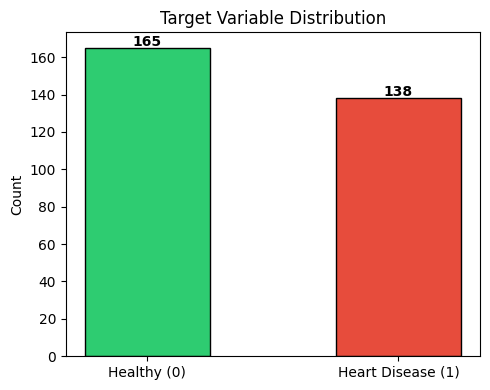

In [101]:
target_counts = heart_data['target'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(['Healthy (0)', 'Heart Disease (1)'], target_counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2. Age Distribution by Target

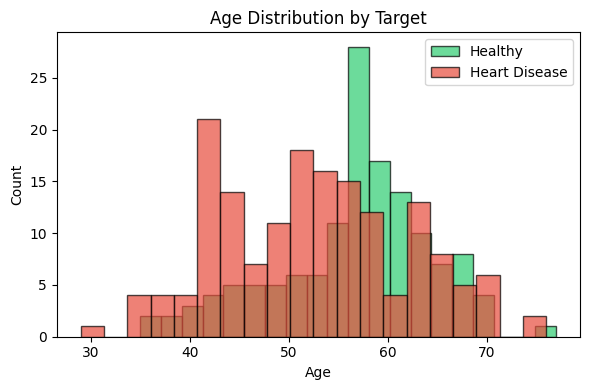

In [102]:
plt.figure(figsize=(6, 4))
plt.hist(heart_data[heart_data['target']==0]['age'], bins=20,
         alpha=0.7, color='#2ecc71', label='Healthy', edgecolor='black')
plt.hist(heart_data[heart_data['target']==1]['age'], bins=20,
         alpha=0.7, color='#e74c3c', label='Heart Disease', edgecolor='black')
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3. Sex vs Heart Disease

<Figure size 500x400 with 0 Axes>

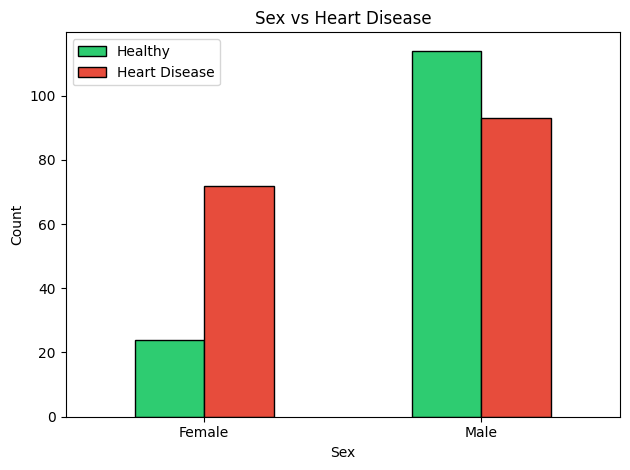

In [103]:
plt.figure(figsize=(5, 4))
sex_target = heart_data.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                edgecolor='black', width=0.5)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.ylabel('Count')
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

### 4. Chest Pain Type vs Heart Disease

<Figure size 600x400 with 0 Axes>

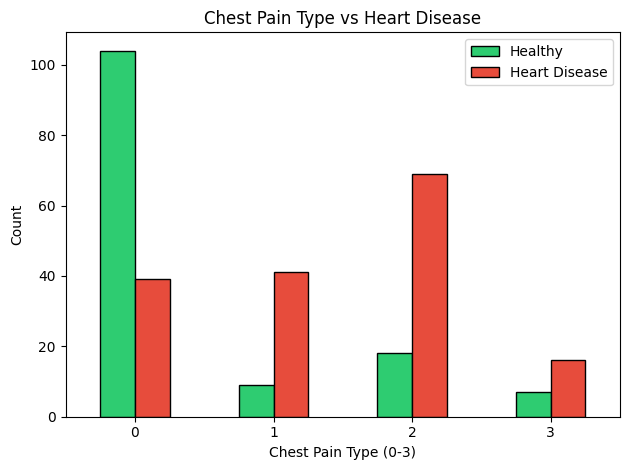

In [104]:
plt.figure(figsize=(6, 4))
cp_target = heart_data.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.5)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

### 5. Max Heart Rate by Target

/tmp/ipykernel_91733/4186936810.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Healthy', 'Heart Disease'],


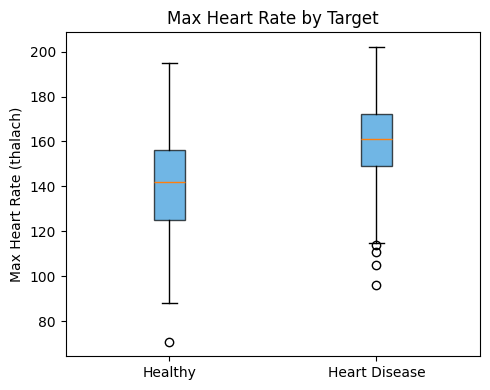

In [105]:
plt.figure(figsize=(5, 4))
data_to_plot = [heart_data[heart_data['target']==0]['thalach'],
                heart_data[heart_data['target']==1]['thalach']]
plt.boxplot(data_to_plot, labels=['Healthy', 'Heart Disease'],
            patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Max Heart Rate by Target')
plt.ylabel('Max Heart Rate (thalach)')
plt.tight_layout()
plt.show()

### 6. Feature Correlation Heatmap

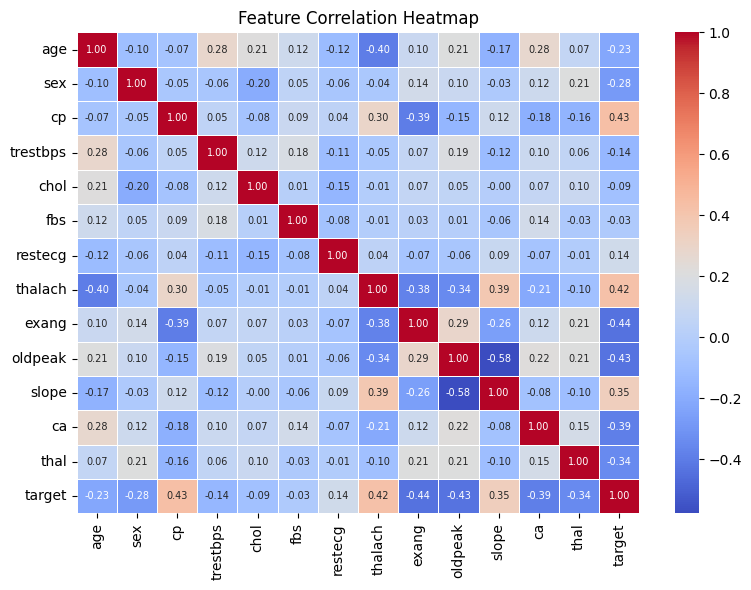

In [106]:
plt.figure(figsize=(8, 6))
corr = heart_data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Splitting the Features and Target

In [107]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [108]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [109]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


Splitting the Data into Training data & Test Data

In [110]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

Feature Encoding & Scaling

In [111]:
# Encoding categorical features and scaling numerical features
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Create a column transformer with encoding and scaling
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Fit the preprocessor on training data and transform both train and test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [112]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 29) (61, 29)


Model Training

Gradient Boosting Classifier

In [113]:
# Import required libraries
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Initialize with stronger regularization & early stopping
model = GradientBoostingClassifier(
    n_estimators=500,           # Start high; early stopping will cut it short
    learning_rate=0.05,         # Lower LR = smoother convergence, less overfitting
    max_depth=2,                # Lower depth for less overfitting
    subsample=0.7,              # Stronger stochastic sampling
    min_samples_split=10,       # More samples to split
    min_samples_leaf=5,         # Larger leaves for smoother predictions
    n_iter_no_change=15,        # Early stopping: stop if val score doesn't improve
    validation_fraction=0.2,    # Hold out 20% of train data for early stopping
    random_state=42
)

# Focused hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5]
}

# Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, Y_train)
best_model = grid_search.best_estimator_
print(f"✅ Best Parameters: {grid_search.best_params_}")

✅ Best Parameters: {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 5}


In [114]:
# training the GradientBoostingClassifier model with Training data
model.fit(X_train, Y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

Model Evaluation

Accuracy Score

In [115]:
# accuracy on training data using best_model
X_train_prediction = best_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [116]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.9049586776859504


In [117]:
# accuracy on test data using best_model
X_test_prediction = best_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [118]:
print('Accuracy on Test data : ', test_data_accuracy)

Accuracy on Test data :  0.7540983606557377


Confusion Matrix

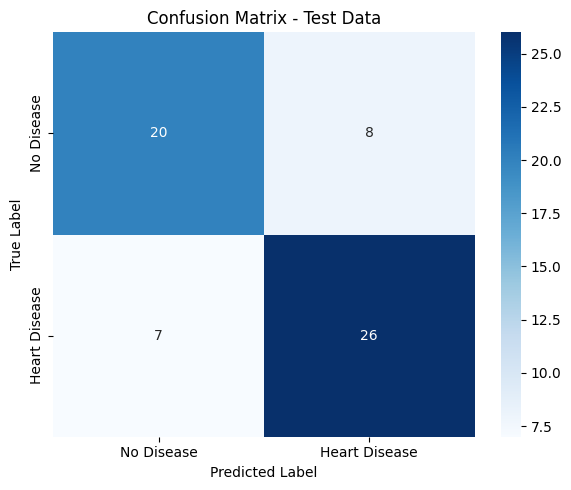


Classification Report:

               precision    recall  f1-score   support

   No Disease       0.74      0.71      0.73        28
Heart Disease       0.76      0.79      0.78        33

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61



In [119]:
# Confusion Matrix on Test Data using best_model
cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Data')
plt.tight_layout()
plt.show()

print('\nClassification Report:\n')
print(classification_report(Y_test, X_test_prediction, target_names=['No Disease', 'Heart Disease']))

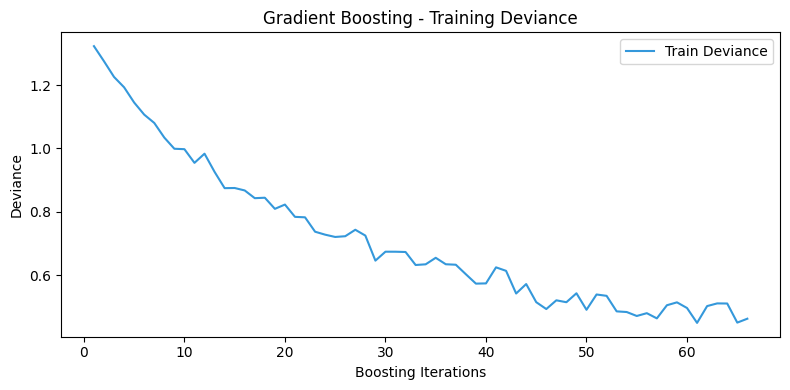

In [120]:
# Learning Curve - Training vs Validation Loss
train_scores_gb = model.train_score_
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_scores_gb) + 1), train_scores_gb,
         color='#3498db', label='Train Deviance')
plt.title('Gradient Boosting - Training Deviance')
plt.xlabel('Boosting Iterations')
plt.ylabel('Deviance')
plt.legend()
plt.tight_layout()
plt.show()

Building a Predictive System

In [121]:
input_data = (63,1,3,145,233,1,0,150,0,2.3,0,0,1)

# Column names must match training data
columns = X.columns.tolist()

# Convert to DataFrame to apply preprocessor
input_df = pd.DataFrame([input_data], columns=columns)

# Apply the same preprocessor used during training
input_transformed = preprocessor.transform(input_df)

prediction = model.predict(input_transformed)
print(prediction)

if (prediction[0] == 0):
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')


[1]
The Person has Heart Disease
